In [1]:
%matplotlib ipympl
from wavesongs.object import Syllable, Song, Synthetic
from wavesongs.data.manager import ProjDirs
from wavesongs.utils import plot
from wavesongs.data.download import xc_url
from wavesongs.utils.math import sinusoidal, fitting, gaussian

# Functions to generate synthetic data
from wavesongs.core.bird import Model

Downloaded audio to XC422161 - Rufous-collared Sparrow - Zonotrichia capensis.mp3


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


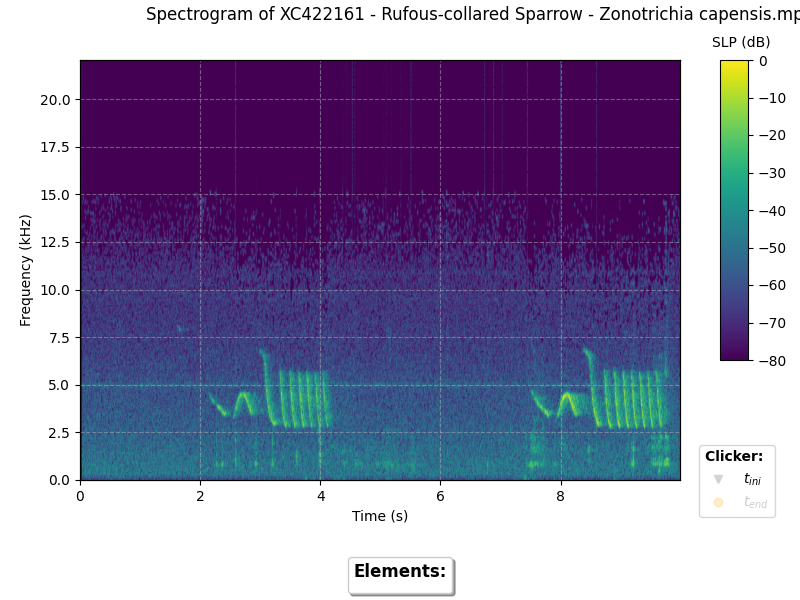

In [2]:
# Download the audio file
file_name = xc_url("https://xeno-canto.org/422161/download")
# Define project directory and plotter objects
proj_dirs = ProjDirs(audios='.')
ploter = plot.set_plotter()

# Define the bem te vi song and compute acoustical features
btv = Song(file_id=file_name , tlim=(0, 10), proj_dirs=proj_dirs) 
btv.acoustical_features(umbral_FF=1.2, n_fft=512, ff_method="yin")
  
# This enables clicking on the spectrogram to get time and frequency values
# Since we are working ina siples example the times were previously clickeed
clicker = ploter.spectrogram(btv, type="2d", ff=False, click="time")

Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


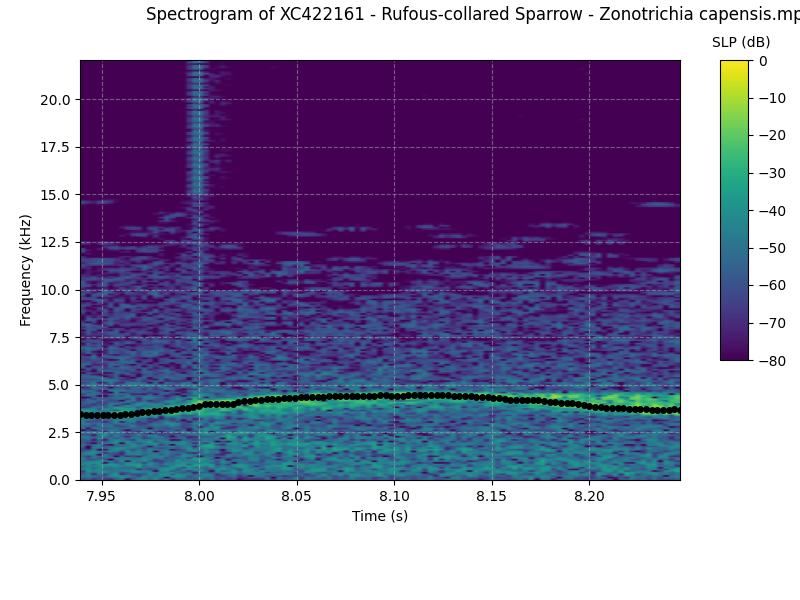

In [3]:
# enable it if you selected the data from the previous cell
# times = plot.get_roi(clicker)
times = [
    # --------------- theme --------------- # Syllable
    (7.513580126621314, 7.789174732335599), # 1
    (7.938880444081631, 8.25870628281179),  # 2
    (8.382893975510202, 8.644878971065758), # 3
    # ---------------- trill ---------------
    (8.723134229478458, 8.845620720907027), # 4
    (8.877943545034013, 8.993625231383218), # 5
    (9.034454061859408, 9.138227339319725), # 6
    (9.16884896217687, 9.270921038367344),  # 7
    (9.308347466303852, 9.405315938684804), # 8
    (9.444443567891152, 9.538009637732424), # 9
    (9.589045675827661, 9.684312946938773)  # 10
]

# Create a song using the second syllable, index 1, and compute its acoustical features
btv_0 = Song(file_id=file_name , tlim=times[1], proj_dirs=ProjDirs(audios='.')) 
btv_0.acoustical_features(umbral_FF=1.4, n_fft=512, ff_method="yin")
  
_ = plot.set_plotter().spectrogram(btv_0, type="2d", ff=True)
btv_0.play()

exponential fit metrics: R^2=-14.3090, RMSE=0.3299
 exponential: [ 2.04897714e+03  4.59039665e-04 -2.04507555e+03]
polynomial fit metrics: R^2=0.9545, RMSE=0.0710
 polynomial: [ 4.40656399  0.13901422 -1.0608086   0.0093371 ]
sinusoidal fit metrics: R^2=0.9790, RMSE=0.0488
 sinusoidal: [ 3.85447872  0.61435327  2.37538776 -0.14213893]


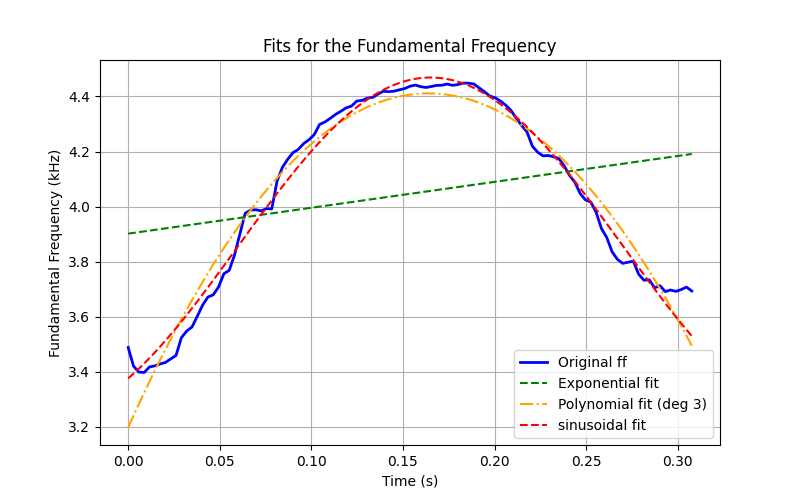

In [4]:
# Fit the fundamental frequency from the selected syllable
plot.fittings_comparison(btv_0, verbose=True)

sinusoidal fit metrics: R^2=0.9790, RMSE=0.0488
 sinusoidal: [ 3.85447872  0.61435327  2.37538776 -0.14213893]


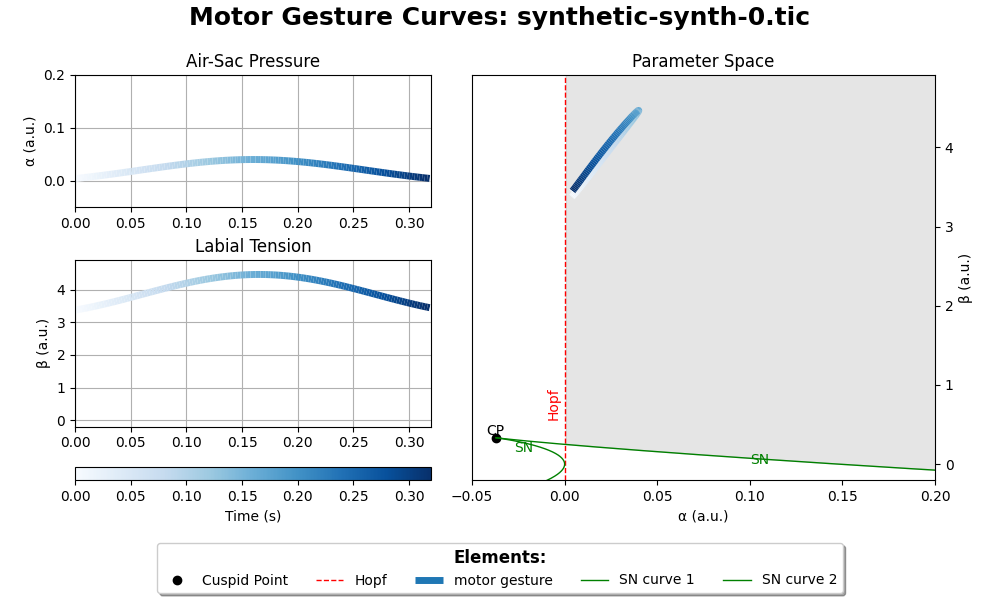

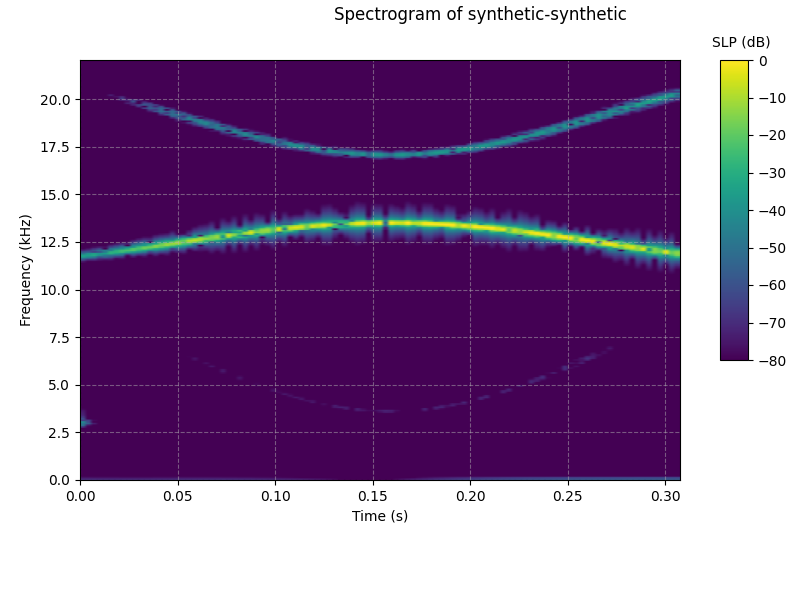

In [ ]:
# Compute a fit for the ff of the selected syllable
fit_sin, params = fitting(btv_0, function="sinusoidal", verbose=True)

# Define the model to use and the over sampling rate
model = Model(ovsr=10)

# Create synthetic syllable
duration = btv_0.time_s[-1]
synthetic = Synthetic(duration=duration, proj_dirs=proj_dirs, sr=44100)
synthetic.initialize()

# Define the control parameters
curves = [
    gaussian(btv_0.time_s, 0.05, duration/2, sigma=0.1, a1=-0.01), # alpha 
    sinusoidal(btv_0.time_s, *params),                             # beta
]

synthetized = model.motor_gesture(synthetic, curves)
synthetized.acoustical_features(umbral_FF=1.4, n_fft=512, ff_method="yin")

# Plot the motor gesture and waveform and spectrogram generated
_ = ploter.alpha_beta(synthetized, save=False)
_ = ploter.spectrogram(synthetized, save=False)

# Play the synthetized syllable
synthetized.play()

 Initial parameters: [ 3.85447872  0.61435327  2.37538776 -0.14213893]
 Modified parameters: [ 0.3         0.1         2.47538776 -0.14213893]


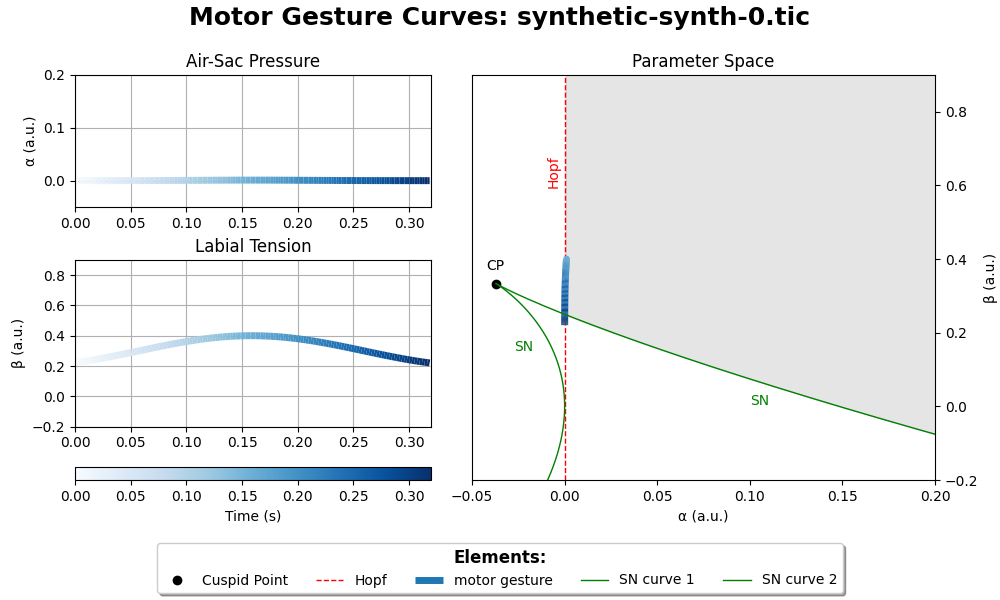

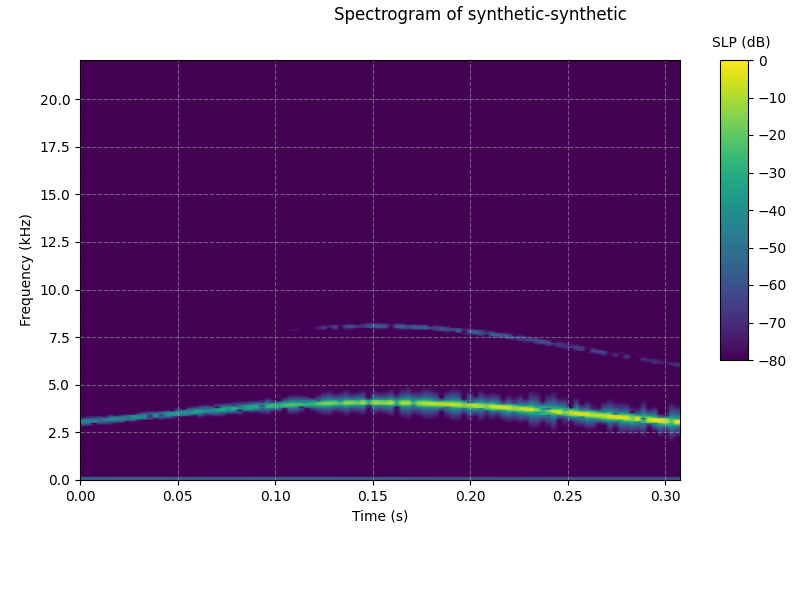

In [ ]:
# Define the control parameters, sinusoidal function: A + B sin (C t + D)
params1 = params.copy()
params1[0] = 0.3 # shitf beta to below
params1[1] = 0.1  # decrease amplitude
params1[2] += 0.1 # frequency
params1[3] += 0  # phase shift
print(f" Initial parameters: {params}\nModified parameters: {params1}")

# Define motor gesture curve functios
curves = [
    gaussian(btv_0.time_s, 0.001, duration/2, sigma=0.05, a1=0),  # alpha 
    sinusoidal(btv_0.time_s, *params1),                           # beta
]

# Define the synthetic syllable and compute its acoustical features
btv_synth = model.motor_gesture(synthetic, curves)
btv_synth.acoustical_features(umbral_FF=1.4, n_fft=512, ff_method="yin")

# Plot the motor gesture and waveform and spectrogram generated
_ = ploter.alpha_beta(btv_synth, save=False)
_ = ploter.spectrogram(btv_synth, save=False)

# Play the synthetized syllable
btv_synth.play()